In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error

In [3]:
df = pd.read_csv("/content/SeoulBikeData.csv", encoding='latin1')

In [4]:
df.head(10)

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.00,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.00,0.0,0.0,Winter,No Holiday,Yes
5,01/12/2017,100,5,-6.4,37,1.5,2000,-18.7,0.00,0.0,0.0,Winter,No Holiday,Yes
6,01/12/2017,181,6,-6.6,35,1.3,2000,-19.5,0.00,0.0,0.0,Winter,No Holiday,Yes
7,01/12/2017,460,7,-7.4,38,0.9,2000,-19.3,0.00,0.0,0.0,Winter,No Holiday,Yes
8,01/12/2017,930,8,-7.6,37,1.1,2000,-19.8,0.01,0.0,0.0,Winter,No Holiday,Yes
9,01/12/2017,490,9,-6.5,27,0.5,1928,-22.4,0.23,0.0,0.0,Winter,No Holiday,Yes


In [5]:
df.shape

(8760, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

In [7]:
LE = LabelEncoder()
df['Date'] = LE.fit_transform(df['Date'])
df['Seasons'] = LE.fit_transform(df['Seasons'])
df['Holiday'] = LE.fit_transform(df['Holiday'])
df['Functioning Day'] = LE.fit_transform(df['Functioning Day'])

In [9]:
SS = StandardScaler()
df['Rented Bike Count'] = SS.fit_transform(df[['Rented Bike Count']])
df['Visibility (10m)'] = SS.fit_transform(df[['Visibility (10m)']])

In [10]:
df.head(10)

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,11,-0.698650,0,-5.2,37,2.2,0.925871,-17.6,0.00,0.0,0.0,3,1,1
1,11,-0.776175,1,-5.5,38,0.8,0.925871,-17.6,0.00,0.0,0.0,3,1,1
2,11,-0.824240,2,-6.0,39,1.0,0.925871,-17.7,0.00,0.0,0.0,3,1,1
3,11,-0.926571,3,-6.2,40,0.9,0.925871,-17.6,0.00,0.0,0.0,3,1,1
4,11,-0.971535,4,-6.0,36,2.3,0.925871,-18.6,0.00,0.0,0.0,3,1,1
5,11,-0.937425,5,-6.4,37,1.5,0.925871,-18.7,0.00,0.0,0.0,3,1,1
6,11,-0.811836,6,-6.6,35,1.3,0.925871,-19.5,0.00,0.0,0.0,3,1,1
7,11,-0.379251,7,-7.4,38,0.9,0.925871,-19.3,0.00,0.0,0.0,3,1,1
8,11,0.349475,8,-7.6,37,1.1,0.925871,-19.8,0.01,0.0,0.0,3,1,1
9,11,-0.332737,9,-6.5,27,0.5,0.807502,-22.4,0.23,0.0,0.0,3,1,1


In [11]:
df.isnull().sum()

,0
Date,0
Rented Bike Count,0
Hour,0
Temperature(°C),0
Humidity(%),0
Wind speed (m/s),0
Visibility (10m),0
Dew point temperature(°C),0
Solar Radiation (MJ/m2),0
Rainfall(mm),0


In [12]:
X = df.drop(columns = 'Rented Bike Count',axis = 1)
Y = df['Rented Bike Count']

In [13]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.2,random_state = 42)

In [14]:
model = LinearRegression()

In [15]:
model.fit(X_train,Y_train)

LinearRegression()

In [16]:
y_pred = model.predict(X_test)

In [19]:
r2 = r2_score(Y_test,y_pred)
mse = mean_squared_error(Y_test,y_pred)

In [20]:
r2

0.5329632943834739

In [21]:
mse

0.46779119105901146

In [22]:
input = [[11,0,-5.2,37,2.2,0.925871,-17.6,0.00,0.0,0.0,3,1,1]]

In [23]:
new_bike_rent = model.predict(input)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [24]:
print("New Predicted Bike Rent :",new_bike_rent[0])

New Predicted Bike Rent : -1.1106207304442768


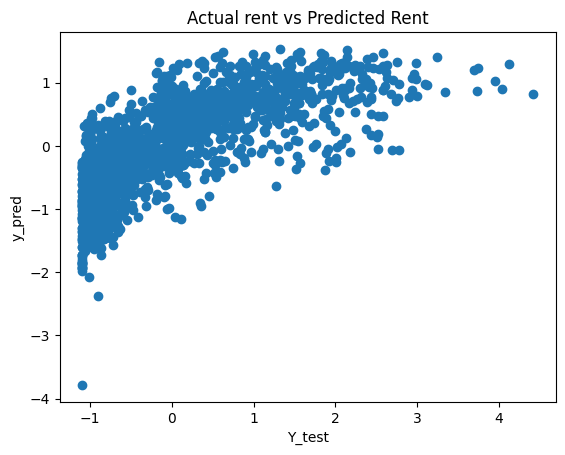

In [25]:
plt.scatter(Y_test,y_pred)
plt.xlabel("Y_test")
plt.ylabel("y_pred")
plt.title("Actual rent vs Predicted Rent")
plt.show()